In [1]:
#importing libraries 

import pandas as pd
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import randint
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFECV
from sklearn.decomposition import PCA
from sklearn.feature_selection import chi2, VarianceThreshold
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder , LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

data = pd.read_csv("../input/house-prices-advanced-regression-techniques/train.csv") 

In [2]:
data=data.set_index('Id') #for reseting index as Id
data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
data['MSZoning'].apply(str)

Id
1       RL
2       RL
3       RL
4       RL
5       RL
        ..
1456    RL
1457    RL
1458    RL
1459    RL
1460    RL
Name: MSZoning, Length: 1460, dtype: object

In [4]:
data.isna().sum().sort_values(ascending = False) # to see nan values

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
FireplaceQu     690
               ... 
Heating           0
HeatingQC         0
MSZoning          0
1stFlrSF          0
SalePrice         0
Length: 80, dtype: int64

In [5]:
P1 =data[['Alley','PoolQC','Fence','MiscFeature','FireplaceQu']]
per =P1.isnull().sum()/len(P1)*100 # to check null values in percentage
per

Alley          93.767123
PoolQC         99.520548
Fence          80.753425
MiscFeature    96.301370
FireplaceQu    47.260274
dtype: float64

In [6]:
#Percentage of missing values is more then 80% 

data=data.drop(['Alley','PoolQC','Fence','MiscFeature'], axis = 1)
data.shape

(1460, 76)

# Correlation matrix

In [7]:
## correlation matrix

## get correlations
data_corr = data.corr()

## irrelevant fields to be defined
fields = ['SalePrice']

## drop rows if needed
data_corr.drop(fields, inplace=True)

## drop cols if needed
data_corr.drop(fields, axis=1, inplace=True)

data_corr.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
MSSubClass,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,...,-0.098672,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407
LotFrontage,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.344997,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450
LotArea,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.180403,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261
OverallQual,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,...,0.562022,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347
OverallCond,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,...,-0.151521,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950


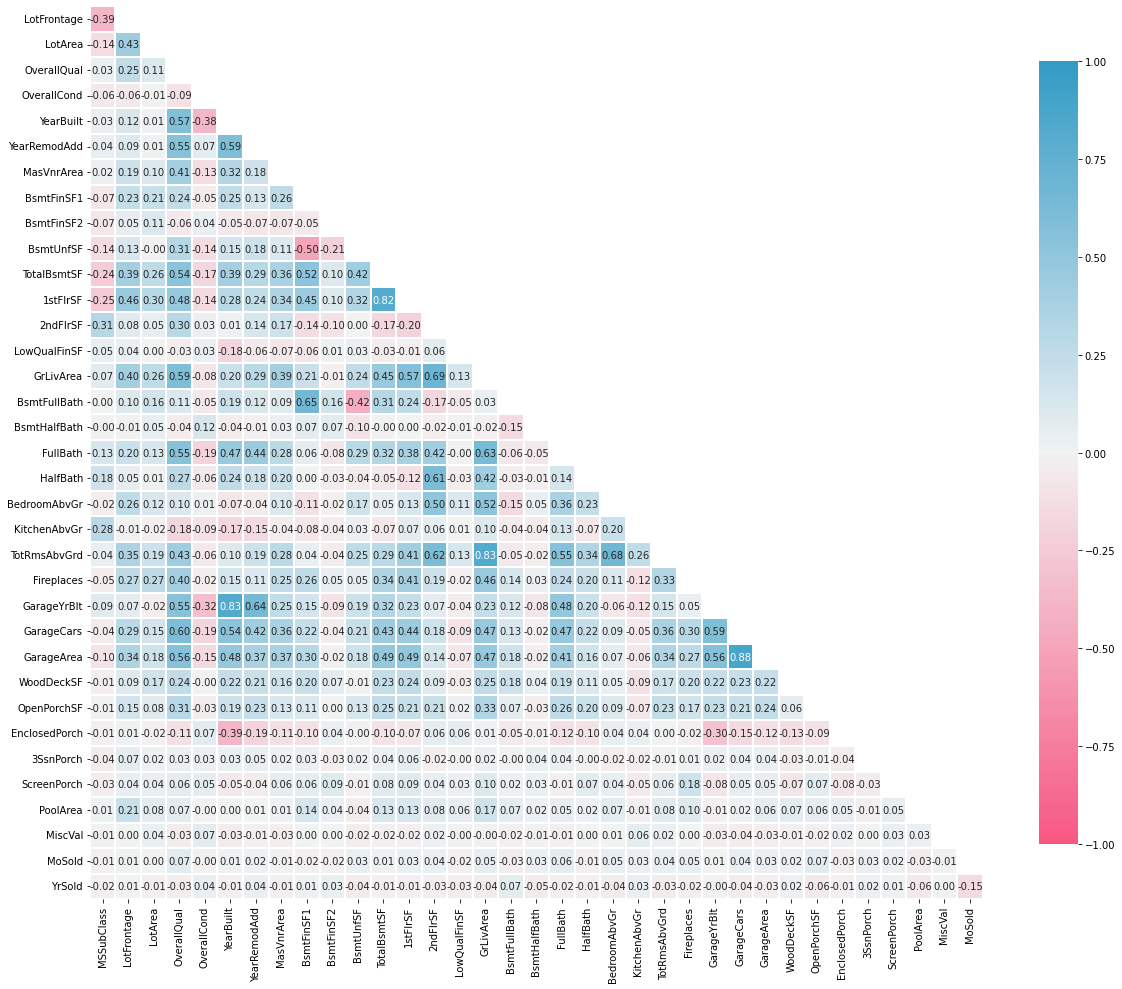

In [8]:
## plotting the heatmap to identify highly correlated features 

fig, ax = plt.subplots(figsize=(20,18))
## mask
mask = np.triu(np.ones_like(data_corr, dtype=np.bool_))

## adjust mask and df
mask = mask[1:, :-1]
corr = data_corr.iloc[1:,:-1].copy()

## color map
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## plot heatmap
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
           linewidths=2,
           vmin=-1, vmax=1, cbar_kws={"shrink": .8},square=True)

## yticks
plt.yticks(rotation=0)
plt.show()


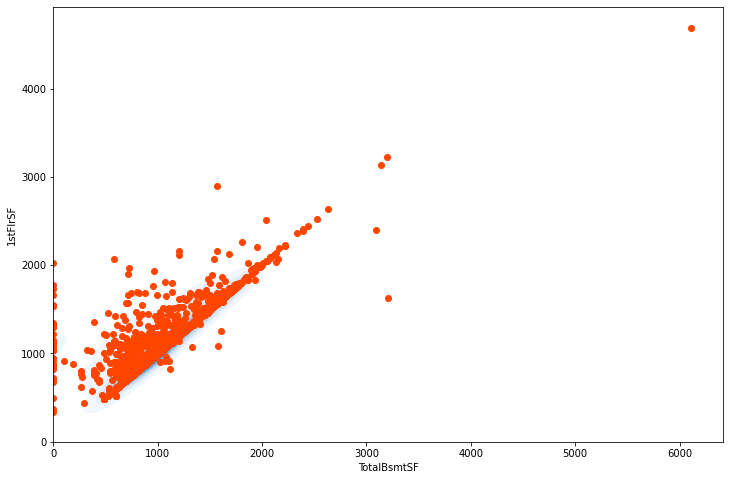

In [9]:
## checking the correlationship between two variables

fig, ax = plt.subplots(1, figsize=(12,8))
sns.kdeplot(data = data, y='1stFlrSF', x='TotalBsmtSF', cmap='Blues',
           shade=True, thresh=0.05, clip=(-1,2000))
plt.scatter(y=data['1stFlrSF'], x=data['TotalBsmtSF'], color='orangered')

In [10]:
#drop the traget column
X= data
y= X.pop('SalePrice')

In [11]:
print(data.shape)

(1460, 75)


# Spliting the data set

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state= 999999)

In [13]:
# select categorical and numerical column names
X_cat_columns = X.select_dtypes(exclude="number").copy().columns 
X_num_columns = X.select_dtypes(include="number").copy().columns

# create numerical pipeline, only with the SimpleImputer(strategy="median") and data scaling
scaler = MinMaxScaler()
numeric_pipe = make_pipeline(scaler,
                             SimpleImputer(strategy="median"))
                             
 
# create categorical pipeline, with the SimpleImputer(fill_value="N_A") and the OneHotEncoder

categoric_pipe = make_pipeline(
    SimpleImputer(strategy="most_frequent"), # you can select this one also strategy="constant", fill_value="N_A"
    OneHotEncoder(handle_unknown = 'ignore', sparse=False) # covert all categorical data in the form of 0 and 1
)

Pipelines can contain many different steps inside. I would divide them into 2 groups: Preprocessing pipelines and Modelling pipelines. A Modelling pipeline has a model as their last step, whereas a preprocessing pipeline doesn't.


- Preprocessing pipelines: Those pipelines only transform the predictor features (the X) by filling NAs, encoding categorical features, scaling, etc. You always have to fit them with X_train. Then, you can call the .transform() method to transform both the X_train and the X_test. (Sometimes, you fit and transform X_train in a single step, by using the .fit_transform() method, but you're still performing these 2 separate steps). Any time that you call transform() you get as an output the transformed data, X_train or X_test.

In [14]:
from sklearn.compose import ColumnTransformer  #make_column_Transformer then dont need to mention names

preprocessor = ColumnTransformer(
    transformers=[
        ("num_pipe", numeric_pipe, X_num_columns),
        ("cat_pipe", categoric_pipe, X_cat_columns)
      
    ]
)

In [15]:
# To display pipeline
from sklearn import set_config
set_config(display = 'diagram')

## Using Linear Regression
The variable(SalePrice) you want to predict is called the dependent variable.

In [16]:
performances = {}

In [17]:
preprocessor.fit_transform(X_train).shape

(1168, 273)

In [18]:
from sklearn.linear_model import LinearRegression
full_pipe_LR = make_pipeline(
    preprocessor,
    LinearRegression())

full_pipe_LR.fit(X_train, y_train)

LR_pred = full_pipe_LR.predict(X_test)

performances["baseline_LR"]= r2_score(y_test, LR_pred)
performances

{'baseline_LR': -2.56742604983682e+19}

In [19]:
# LR with PCA 

from sklearn.linear_model import LinearRegression
full_pipe_LR = make_pipeline(
    preprocessor,
    PCA(n_components=97),
    LinearRegression())

full_pipe_LR.fit(X_train, y_train)

LR_pred = full_pipe_LR.predict(X_test)

performances["PCA95_LR"]= r2_score(y_test, LR_pred)
performances

{'baseline_LR': -2.56742604983682e+19, 'PCA95_LR': 0.8822106667629063}

##XGBRegressor

In [20]:
from xgboost import XGBRegressor

#Using pipeline
full_pipe_XGB = make_pipeline(
    preprocessor,
    XGBRegressor(n_estimators=950,learning_rate=0.05,n_jobs=-1))

full_pipe_XGB.fit(X_train, y_train)

XGB_pred = full_pipe_XGB.predict(X_test)

performances["XGB_pred"]= r2_score(y_test, XGB_pred)
performances

{'baseline_LR': -2.56742604983682e+19,
 'PCA95_LR': 0.8822106667629063,
 'XGB_pred': 0.897516930267088}

## Using Random Forest Regressor

In [21]:
from sklearn.ensemble import RandomForestRegressor
RF = RandomForestRegressor(n_estimators=150, random_state=0)

In [22]:
full_pipeline = make_pipeline(preprocessor,
                              RF)

In [23]:
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num_pipe',
                                                  Pipeline(steps=[('minmaxscaler',
                                                                   MinMaxScaler()),
                                                                  ('simpleimputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1st...
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('randomforestregressor',
                 RandomForestRegressor(n_estimators=150, random_state=0))])

In [24]:
preds = full_pipeline.predict(X_train)
preds[0:5]

array([170191.41333333, 174646.04      , 149578.88      , 299698.18666667,
       135874.        ])

### Check on test file

In [25]:
test_data = pd.read_csv("../input/house-prices-advanced-regression-techniques/test.csv")

In [26]:
test_data.set_index("Id", inplace=True)  #reset index as Id

In [27]:
##Percentage of missing values

Pt =test_data[['Alley','PoolQC','Fence','MiscFeature','FireplaceQu']]  
pert =P1.isnull().sum()/len(P1)*100
pert

Alley          93.767123
PoolQC         99.520548
Fence          80.753425
MiscFeature    96.301370
FireplaceQu    47.260274
dtype: float64

In [28]:
# Percentage of missing values is more then 80% then dropp it

test_data=test_data.drop(['Alley','PoolQC','Fence','MiscFeature'], axis = 1)

In [29]:
# To predict test data using XGB full pipeline
test_preds = full_pipe_XGB.predict(test_data)  


In [30]:
# Two cloumns are needed to make dataframe 
result = pd.DataFrame({'Id': test_data.index,             
                       'SalePrice': test_preds})


In [31]:
result

,Id,SalePrice
0,1461,129699.734375
1,1462,153017.593750
2,1463,185872.687500
3,1464,186775.625000
4,1465,190902.812500
...,...,...
1454,2915,85295.210938
1455,2916,80450.695312
1456,2917,165543.156250
1457,2918,105584.359375


In [32]:
# To covert dataframe to CSV
result.to_csv('Submission.csv', index=False)

In [33]:
# For download CSV file from colab
#from google.colab import files
#files.download("Submission.csv")